# Визуализация единой multiclass photoswitch-модели

Notebook читает `generated_multiclass_photoswitch.csv`, полученный одним
conditional SELFIES-GRU с family-токенами `<AZO>` и `<STILBENE>`.

Оба класса имеют явные E/Z-пары и общий UV proxy. Azo дополнительно имеет
обучаемые half-life и E/Z spectral-separation proxies. Для stilbene-like
half-life, PSS, quantum yield, ΔH и stored energy отсутствуют и не подменяются.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from rdkit import Chem, RDLogger
from rdkit.Chem import Draw

RDLogger.DisableLog("rdApp.*")
ROOT = Path.cwd().resolve()
CSV_PATH = ROOT / "generated_multiclass_photoswitch.csv"
df = pd.read_csv(CSV_PATH)
required = {
    "family", "canonical_smiles", "state_A_smiles", "state_B_smiles",
    "pair_valid", "eval_uv_lambda_nm", "eval_uv_uncertainty_nm", "sa_score",
    "reward", "PSS_pred", "quantum_yield_pred", "deltaH_kJ_mol",
    "stored_energy_MJ_kg", "final_status",
}
missing = required.difference(df.columns)
if missing:
    raise KeyError(f"generated_multiclass_photoswitch.csv is missing: {sorted(missing)}")
print(f"Loaded {len(df):,} rows from {CSV_PATH}")
print("Families:", df["family"].value_counts().to_dict())
print("Unique structures:", df.groupby("family")["canonical_smiles"].nunique().to_dict())

/home/dokoo-lua/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-z7q4ewsx because there was an issue with the default path (/home/dokoo-lua/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Loaded 19,626 rows from /home/dokoo-lua/MolGeneration/generated_multiclass_photoswitch.csv
Families: {'stilbene': 14832, 'azo': 4794}
Unique structures: {'azo': 4794, 'stilbene': 14832}


## Размеры классов и итоговые proxy-status

,family,rows,unique,proxy_pass,median_uv_nm,median_uv_uncertainty_nm,median_sa
0,azo,4794,4794,852,406.243412,59.778436,3.486427
1,stilbene,14832,14832,10405,388.565094,59.778436,3.088338


final_status,FAIL_PROXY,PASS_AZO_PROXY,PASS_STILBENE_STRUCTURAL_PROXY
family,,,
azo,3942,852,0
stilbene,4427,0,10405


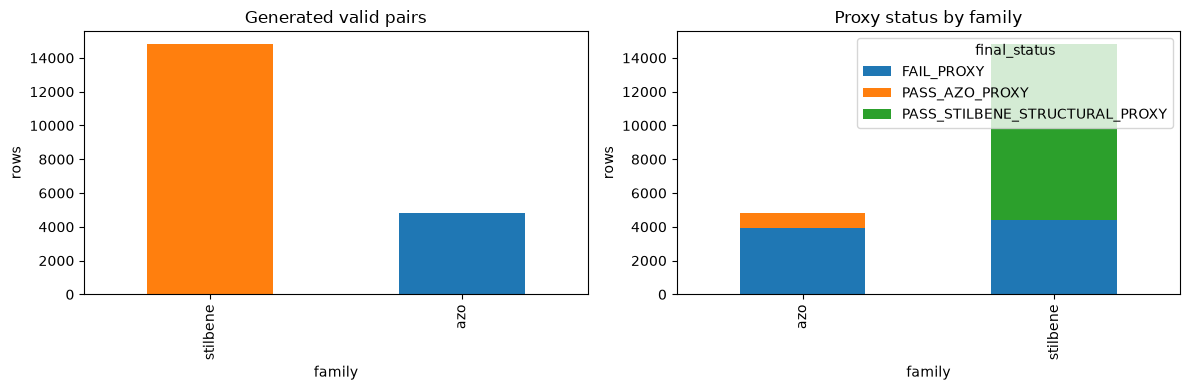

In [2]:
summary = (
    df.groupby("family", as_index=False)
      .agg(
          rows=("canonical_smiles", "size"),
          unique=("canonical_smiles", "nunique"),
          proxy_pass=("final_status", lambda x: int(x.str.startswith("PASS").sum())),
          median_uv_nm=("eval_uv_lambda_nm", "median"),
          median_uv_uncertainty_nm=("eval_uv_uncertainty_nm", "median"),
          median_sa=("sa_score", "median"),
      )
)
display(summary)
display(pd.crosstab(df["family"], df["final_status"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["family"].value_counts().plot.bar(ax=axes[0], color=["tab:orange", "tab:blue"])
axes[0].set(title="Generated valid pairs", xlabel="family", ylabel="rows")
status_table = pd.crosstab(df["family"], df["final_status"])
status_table.plot.bar(stacked=True, ax=axes[1])
axes[1].set(title="Proxy status by family", xlabel="family", ylabel="rows")
plt.tight_layout()
plt.show()

## Общий UV proxy и synthetic accessibility

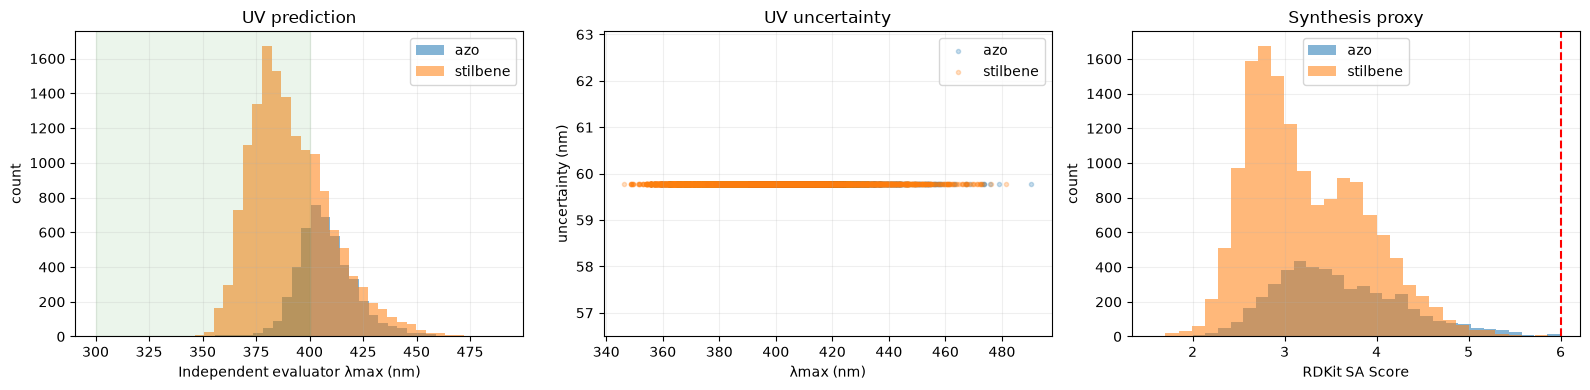

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for family, part in df.groupby("family"):
    axes[0].hist(part["eval_uv_lambda_nm"], bins=30, alpha=0.55, label=family)
    axes[1].scatter(part["eval_uv_lambda_nm"], part["eval_uv_uncertainty_nm"], s=9, alpha=0.25, label=family)
    axes[2].hist(part["sa_score"], bins=30, alpha=0.55, label=family)
axes[0].axvspan(300, 400, color="green", alpha=0.08)
axes[0].set(xlabel="Independent evaluator λmax (nm)", ylabel="count", title="UV prediction")
axes[1].set(xlabel="λmax (nm)", ylabel="uncertainty (nm)", title="UV uncertainty")
axes[2].axvline(6.0, color="red", ls="--")
axes[2].set(xlabel="RDKit SA Score", ylabel="count", title="Synthesis proxy")
for axis in axes:
    axis.legend()
    axis.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Azo-specific spectral separation и half-life

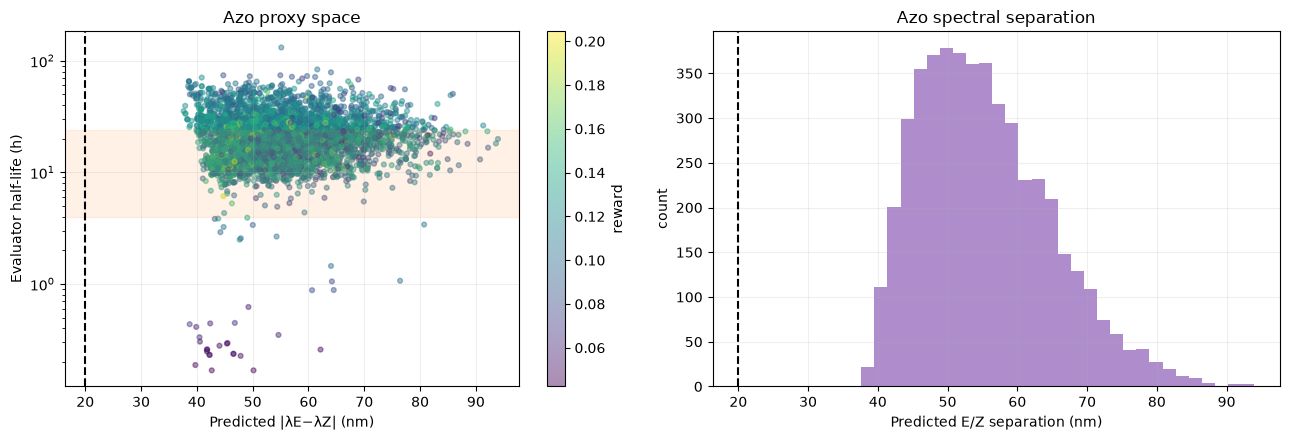

In [4]:
azo = df[df["family"].eq("azo")].dropna(subset=["pred_delta_lambda_nm", "eval_half_life_h"])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
scatter = axes[0].scatter(
    azo["pred_delta_lambda_nm"], azo["eval_half_life_h"],
    c=azo["reward"], cmap="viridis", s=12, alpha=0.45,
)
axes[0].axvline(20, color="black", ls="--")
axes[0].axhspan(4, 24, color="tab:orange", alpha=0.1)
axes[0].set_yscale("log")
axes[0].set(xlabel="Predicted |λE−λZ| (nm)", ylabel="Evaluator half-life (h)", title="Azo proxy space")
fig.colorbar(scatter, ax=axes[0], label="reward")
axes[1].hist(azo["pred_delta_lambda_nm"], bins=30, color="tab:purple", alpha=0.75)
axes[1].axvline(20, color="black", ls="--")
axes[1].set(xlabel="Predicted E/Z separation (nm)", ylabel="count", title="Azo spectral separation")
for axis in axes:
    axis.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Лучшие E/Z-пары каждого класса

,canonical_smiles,state_A_smiles,state_B_smiles,eval_uv_lambda_nm,sa_score,reward,final_status
3053,CC(=C/N=N/C=Cc1ccccc1)c1ccn[nH]1,CC(=C/N=N/C=Cc1ccccc1)c1ccn[nH]1,CC(=C/N=N\C=Cc1ccccc1)c1ccn[nH]1,369.303821,3.317069,0.189772,PASS_AZO_PROXY
4427,CC=NC=CC(C)=CN=NC=Cc1ccccc1,CC=NC=CC(C)=C/N=N/C=Cc1ccccc1,CC=NC=CC(C)=C/N=N\C=Cc1ccccc1,375.099374,3.840597,0.188908,PASS_AZO_PROXY
4695,COC=C(C)C=C/N=N/C=Cc1ccccc1C,COC=C(C)C=C/N=N/C=Cc1ccccc1C,COC=C(C)C=C/N=N\C=Cc1ccccc1C,375.614202,3.560169,0.188177,PASS_AZO_PROXY
4233,CN=NC=Cc1ccccc1Cl,C/N=N/C=Cc1ccccc1Cl,C/N=N\C=Cc1ccccc1Cl,365.504788,2.957373,0.187896,PASS_AZO_PROXY
4357,CC=NC=C(C)C=C/N=N/C=Cc1ccccc1C,CC=NC=C(C)C=C/N=N/C=Cc1ccccc1C,CC=NC=C(C)C=C/N=N\C=Cc1ccccc1C,369.700059,3.941321,0.186316,PASS_AZO_PROXY
263,C#C/N=N/C=Cc1ccccc1C,C#C/N=N/C=Cc1ccccc1C,C#C/N=N\C=Cc1ccccc1C,362.520287,3.415830,0.185637,PASS_AZO_PROXY
1637,C#CN=NC=Cc1ccccc1C,C#C/N=N/C=Cc1ccccc1C,C#C/N=N\C=Cc1ccccc1C,362.520287,3.415830,0.185637,PASS_AZO_PROXY
1014,C#C/N=N/C=Cc1ccccc1Cl,C#C/N=N/C=Cc1ccccc1Cl,C#C/N=N\C=Cc1ccccc1Cl,366.225694,3.418330,0.184915,PASS_AZO_PROXY
2646,CN=C=C/N=N/C=Cc1ccccc1C=Nc1ccccc1,CN=C=C/N=N/C=Cc1ccccc1C=Nc1ccccc1,CN=C=C/N=N\C=Cc1ccccc1C=Nc1ccccc1,371.197076,3.480853,0.184868,PASS_AZO_PROXY


azo: state A


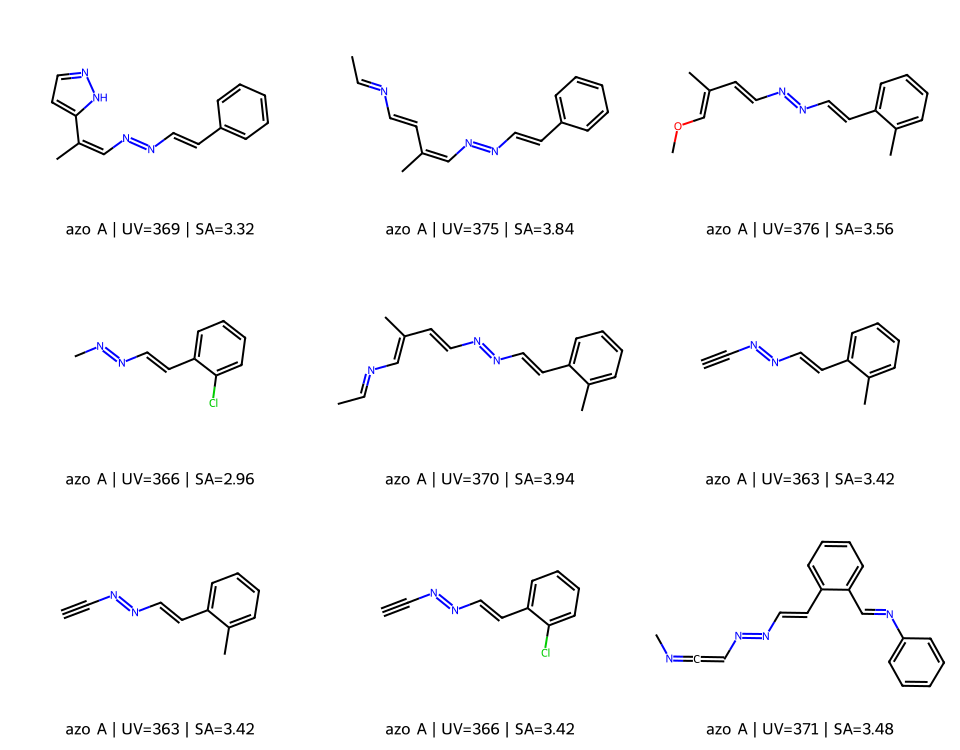

azo: corresponding state B


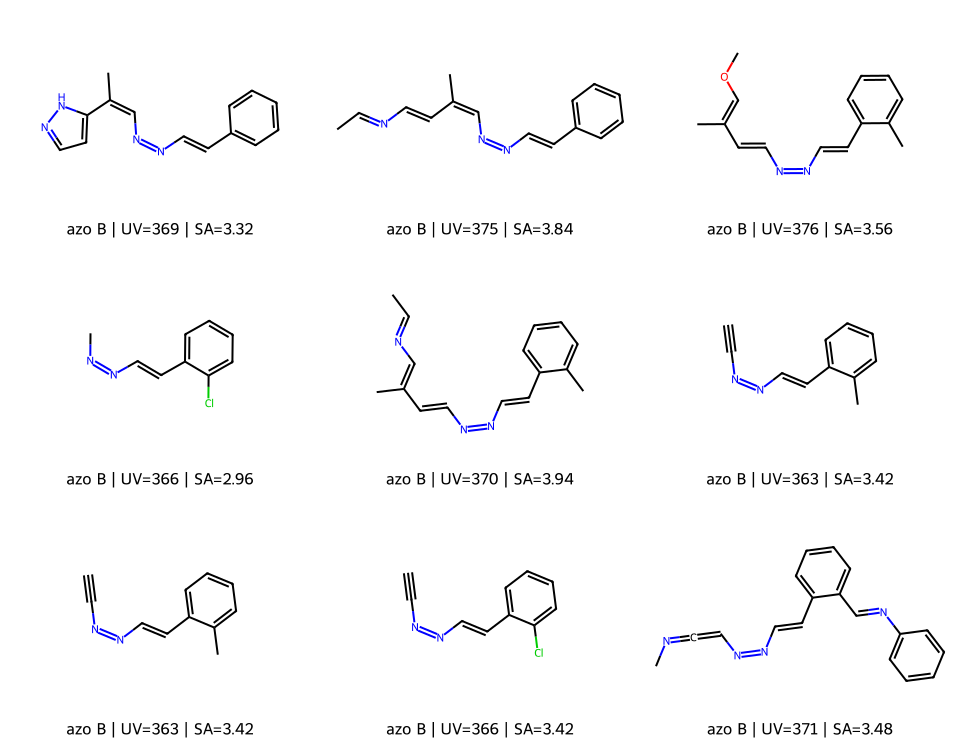

,canonical_smiles,state_A_smiles,state_B_smiles,eval_uv_lambda_nm,sa_score,reward,final_status
7618,Cc1ccccc1C=Cc1ccccc1C=Cc1ccccc1-c1ccccc1C,Cc1ccccc1/C=C/c1ccccc1C=Cc1ccccc1-c1ccccc1C,Cc1ccccc1/C=C\c1ccccc1C=Cc1ccccc1-c1ccccc1C,349.332798,2.035512,0.338354,PASS_STILBENE_STRUCTURAL_PROXY
13186,Cc1ccccc1C=Cc1ccccc1C=Cc1ccccc1C=Cc1ccccc1-c1c...,Cc1ccccc1/C=C/c1ccccc1C=Cc1ccccc1C=Cc1ccccc1-c...,Cc1ccccc1/C=C\c1ccccc1C=Cc1ccccc1C=Cc1ccccc1-c...,349.332798,2.199821,0.338354,PASS_STILBENE_STRUCTURAL_PROXY
13276,Cc1ccccc1C=Cc1ccccc1-c1ccccc1C,Cc1ccccc1/C=C/c1ccccc1-c1ccccc1C,Cc1ccccc1/C=C\c1ccccc1-c1ccccc1C,349.332798,1.850764,0.338354,PASS_STILBENE_STRUCTURAL_PROXY
15424,Cc1ccccc1-c1ccccc1C=Cc1ccccc1-c1ccccc1C,Cc1ccccc1-c1ccccc1/C=C/c1ccccc1-c1ccccc1C,Cc1ccccc1-c1ccccc1/C=C\c1ccccc1-c1ccccc1C,346.251540,1.767216,0.338050,PASS_STILBENE_STRUCTURAL_PROXY
6443,C(=Cc1ccccc2ccccc2ccc2ccccc2ccc1)c1ccccc1,C(=C\c1ccccc2ccccc2ccc2ccccc2ccc1)/c1ccccc1,C(=C/c1ccccc2ccccc2ccc2ccccc2ccc1)/c1ccccc1,349.000854,1.793436,0.337712,PASS_STILBENE_STRUCTURAL_PROXY
15973,Cc1ccccc1C=Cc1cccccc2ccccc2ccc2ccccc2cc1C,Cc1ccccc1/C=C/c1cccccc2ccccc2ccc2ccccc2cc1C,Cc1ccccc1/C=C\c1cccccc2ccccc2ccc2ccccc2cc1C,354.002208,2.249729,0.336565,PASS_STILBENE_STRUCTURAL_PROXY
18000,Cc1ccccc1-c1ccccc1C=Cc1ccccc1Br,Cc1ccccc1-c1ccccc1/C=C/c1ccccc1Br,Cc1ccccc1-c1ccccc1/C=C\c1ccccc1Br,359.310707,1.929644,0.336464,PASS_STILBENE_STRUCTURAL_PROXY
18274,Cc1ccccc1C=Cc1ccccc1C=Cc1ccccc1-c1ccccc1C=Cc1c...,Cc1ccccc1C=Cc1ccccc1-c1ccccc1C=Cc1ccccc1/C=C/c...,Cc1ccccc1C=Cc1ccccc1-c1ccccc1C=Cc1ccccc1/C=C\c...,355.430858,2.147784,0.335859,PASS_STILBENE_STRUCTURAL_PROXY
19006,Cc1ccccc1C=Cc1ccccc1-c1ccccc1C=Cc1ccccc1C,Cc1ccccc1C=Cc1ccccc1-c1ccccc1/C=C/c1ccccc1C,Cc1ccccc1C=Cc1ccccc1-c1ccccc1/C=C\c1ccccc1C,355.430858,1.952682,0.335859,PASS_STILBENE_STRUCTURAL_PROXY


stilbene: state A


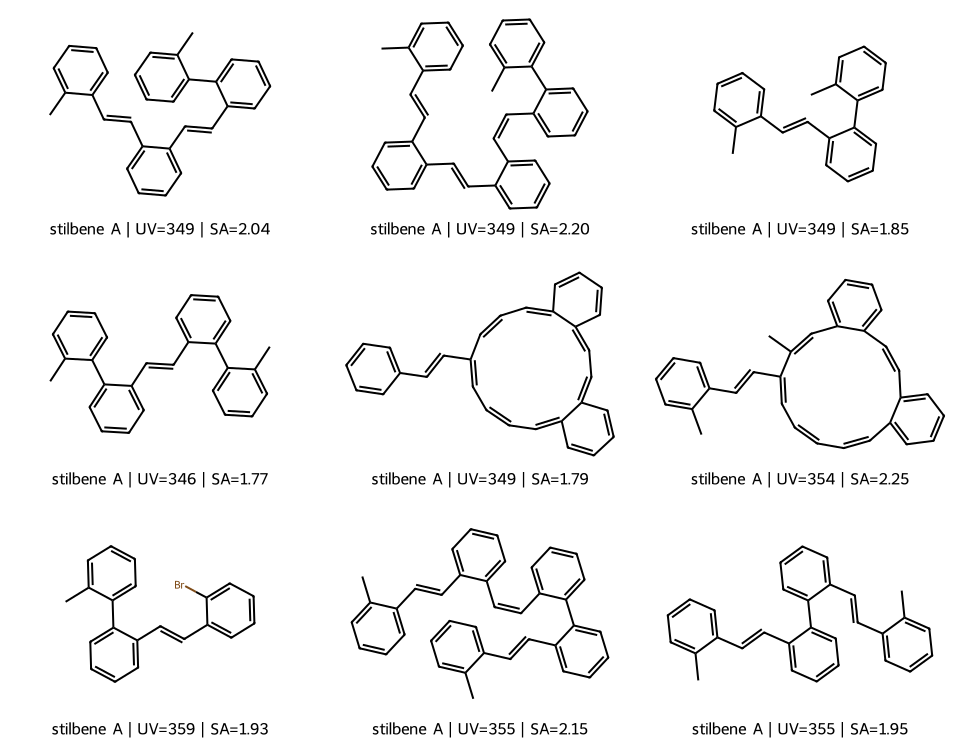

stilbene: corresponding state B


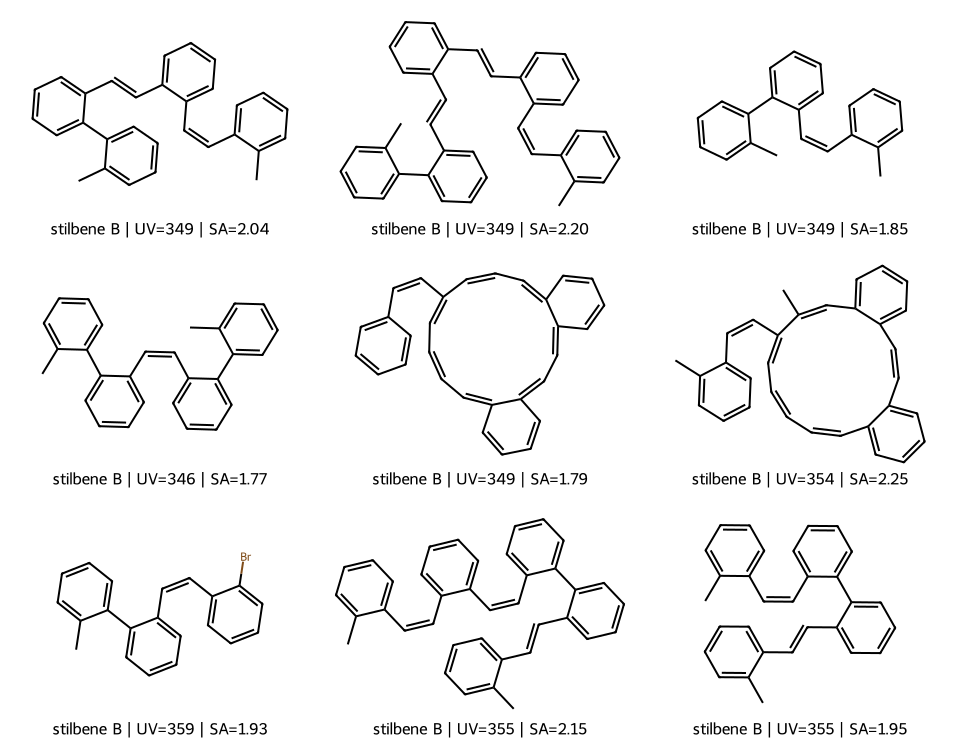

In [5]:
def show_family_pairs(family, count=9):
    top = (
        df[df["family"].eq(family)]
        .sort_values(["final_status", "reward"], ascending=[False, False])
        .drop_duplicates("canonical_smiles")
        .head(count)
    )
    display(top[[
        "canonical_smiles", "state_A_smiles", "state_B_smiles",
        "eval_uv_lambda_nm", "sa_score", "reward", "final_status",
    ]])
    state_a = [Chem.MolFromSmiles(s) for s in top["state_A_smiles"]]
    state_b = [Chem.MolFromSmiles(s) for s in top["state_B_smiles"]]
    legends_a = [f"{family} A | UV={r.eval_uv_lambda_nm:.0f} | SA={r.sa_score:.2f}" for r in top.itertuples()]
    legends_b = [f"{family} B | UV={r.eval_uv_lambda_nm:.0f} | SA={r.sa_score:.2f}" for r in top.itertuples()]
    print(f"{family}: state A")
    display(Draw.MolsToGridImage(state_a, legends=legends_a, molsPerRow=3, subImgSize=(320, 250), useSVG=True))
    print(f"{family}: corresponding state B")
    display(Draw.MolsToGridImage(state_b, legends=legends_b, molsPerRow=3, subImgSize=(320, 250), useSVG=True))

show_family_pairs("azo")
show_family_pairs("stilbene")

### Научная граница результата

Оба класса генерируются одним checkpoint. Для azo доступны M01-derived half-life
и E/Z spectral proxies. Для stilbene-like подтверждены лишь diaryl/heteroaryl
alkene E/Z pair и общий UVVisML proxy. PSS, quantum yield, ΔH и stored energy
намеренно остаются пустыми для обоих классов до физической валидации.